# **Sklearn Adaboost**

### AdaBoost Hyperparameters (sklearn.ensemble)

```python
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor
```


#### Common Hyperparameters:
- **estimator** (formerly `base_estimator`): The base estimator from which the boosted ensemble is built. Default is `DecisionTreeClassifier(max_depth=1)` for classification and `DecisionTreeRegressor(max_depth=3)` for regression. To be frank decision tree works better for ada boost.
    - AdaBoost doesn't suppost KNN.
    - KEEP IN MIND, MORE THE `max_depth` MORE WILL BE THE OVERFITTING.
- **n_estimators**: The maximum number of estimators at which boosting is terminated. In case of perfect fit, the learning procedure is stopped early. Default is `50`.
- **learning_rate**: Weight applied to each classifier at each boosting iteration. A higher learning rate increases the contribution of each classifier. There is a trade-off between `learning_rate` and `n_estimators`. Default is `1.0`.
- **random_state**: Controls the random seed given to each `estimator` at each boosting iteration.

#### AdaBoostClassifier Specific:
- **algorithm**: For algorithm you have two parameters.
    - `'SAMME'`: Uses the SAMME discrete boosting algorithm.
    - `'SAMME.R'`: Uses the SAMME.R real boosting algorithm **(default)**. It relies on class probabilities and generally converges faster than SAMME. Generally faster then SAMME and gives a lower test erros with fewer boosting iterations.

#### AdaBoostRegressor Specific:
- **loss**: The loss function to use when updating the weights after each boosting iteration.
    - `'linear'` (default)
    - `'square'`
    - `'exponential'`



In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor      # importing adaboost
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.datasets import make_classification, make_regression, make_circles
# make_circles : generates a synthetic (artificial) dataset consisting of two rings of points—one circle inside the other
# one of the most popular toy datasets used to test Machine Learning models, coz it is non-linearly separable

from mlxtend.plotting import plot_decision_regions

import warnings
warnings.filterwarnings('ignore')

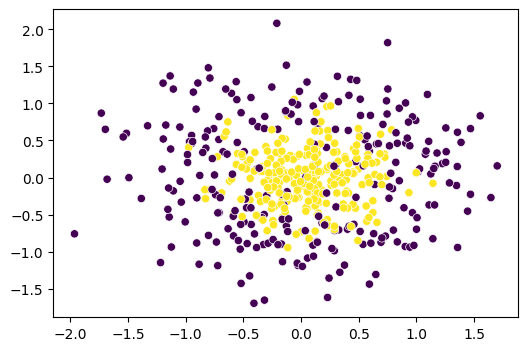

In [95]:
# making the dataset
np.random.seed(42)
X, y = make_circles(
    n_samples=500,
    factor=0.1,
    noise=0.35,     # keep changing the value of noise and you will see how it adds/removes outliers depending upon the number that you put
    random_state=42
)

# plotting the dataset
plt.figure(figsize=(6,4))
sns.scatterplot(x=X[:,0], y=X[:,1], c=y)       # make sure while using scatterplot, you have to mention x and y
plt.show()

In [96]:
abc = AdaBoostClassifier()
print(f"CROSS VAL SCORE : {np.round(np.mean(cross_val_score(abc, X, y, cv=10, scoring='accuracy')), 2)}")

abc.fit(X, y)
ans = abc.predict(X)

print(f"ACCURACY SCORE : {accuracy_score(y, ans)}")




CROSS VAL SCORE : 0.81
ACCURACY SCORE : 0.854


In [97]:
# making a function to plot graph
def plot_decision_boundary(clf):
    plt.figure(figsize=(12, 8))
    x_range = np.linspace(X.min(), X.max(), 100)        # wil make an array of 100 elements of all the numbers btwn min and max value of X 
    xx1, xx2 = np.meshgrid(x_range, x_range)
    y_hat = clf.predict(np.c_[xx1.ravel(), xx2.ravel()])
    y_hat = y_hat.reshape(xx1.shape)
    plt.contourf(xx1, xx2, y_hat, alpha=0.2)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
    plt.title("Adaboost Classifier")
    plt.show()
    


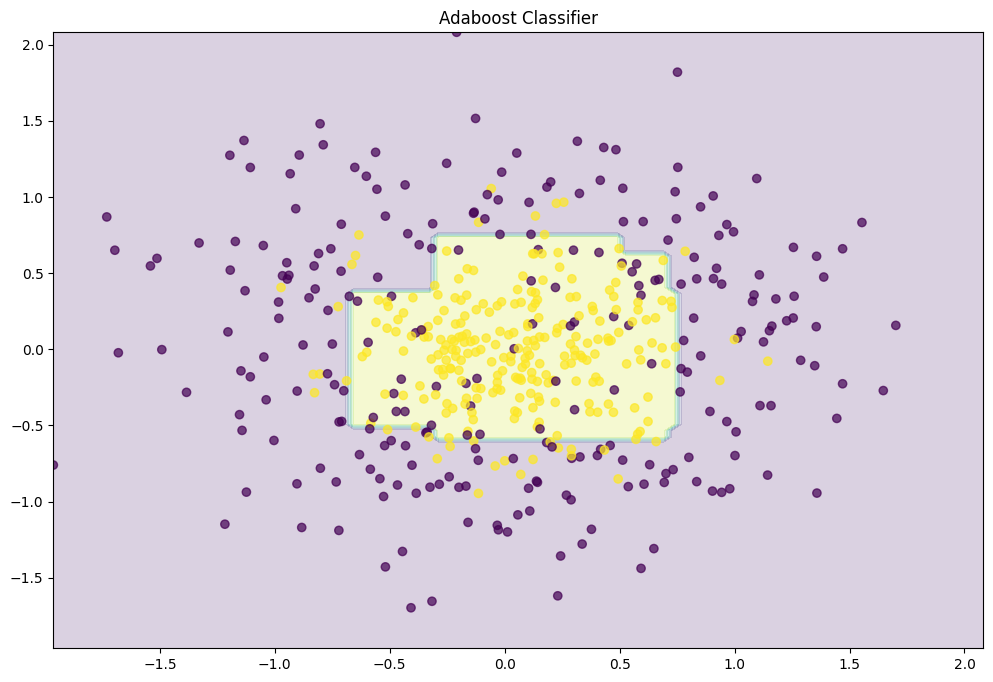

In [98]:
plot_decision_boundary(abc)

keep in mind, there is an inverse relatin btwn estimators and learning rate

ACCURACY SCORE : 0.608


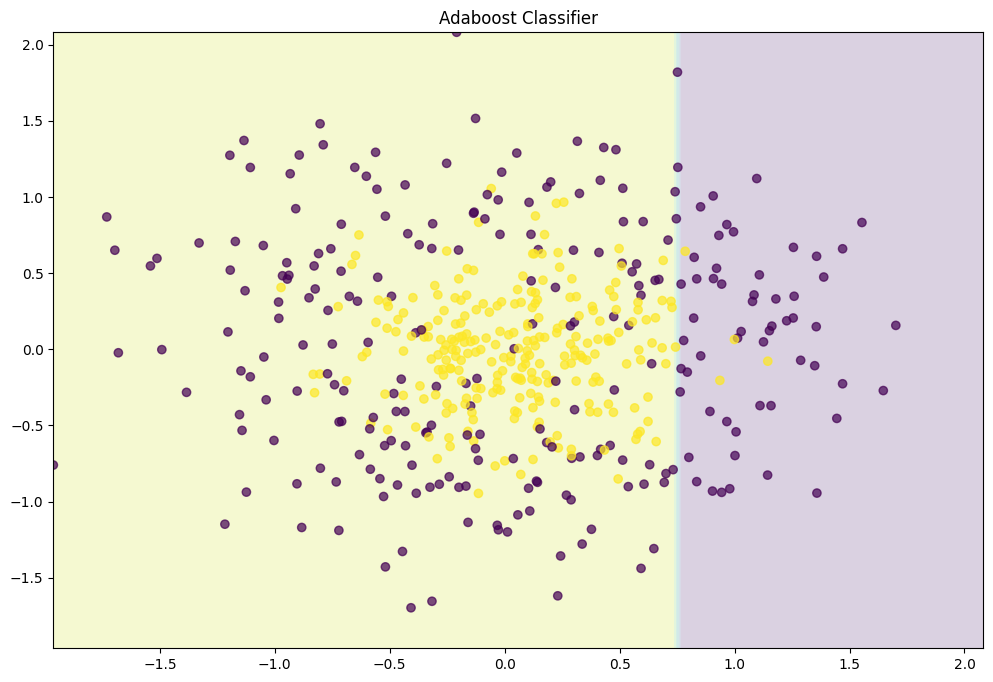

In [99]:
abc = AdaBoostClassifier(n_estimators=1)
abc.fit(X, y)
ans = abc.predict(X)
print(f"ACCURACY SCORE : {accuracy_score(y, ans)}")

plot_decision_boundary(abc)

ACCURACY SCORE : 0.714


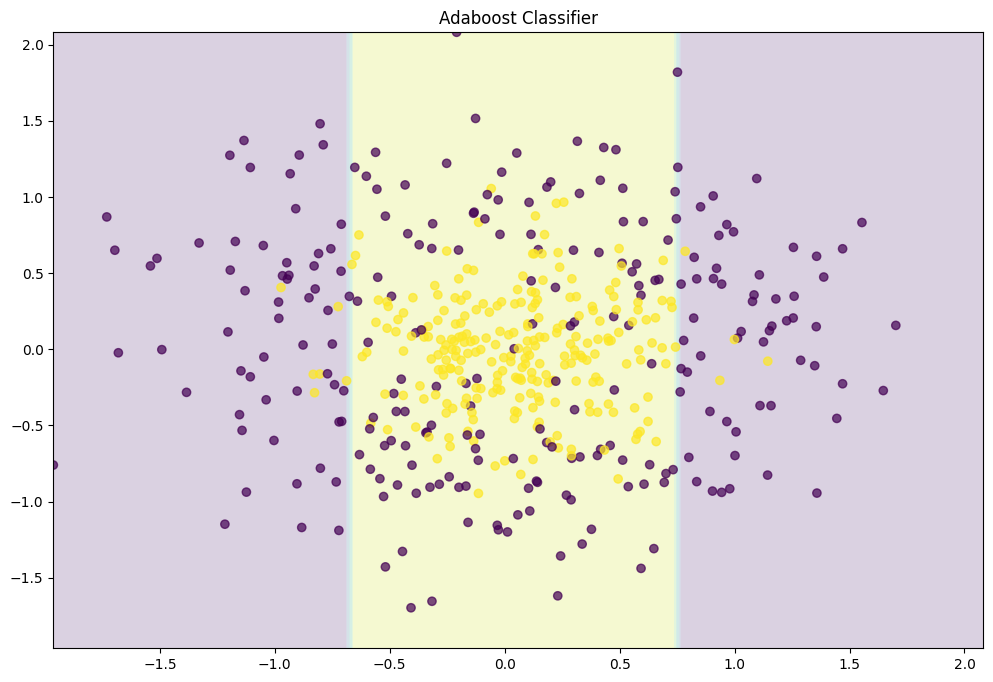

In [100]:
abc = AdaBoostClassifier(n_estimators=3)
abc.fit(X, y)
ans = abc.predict(X)
print(f"ACCURACY SCORE : {accuracy_score(y, ans)}")

plot_decision_boundary(abc)

ACCURACY SCORE : 0.554


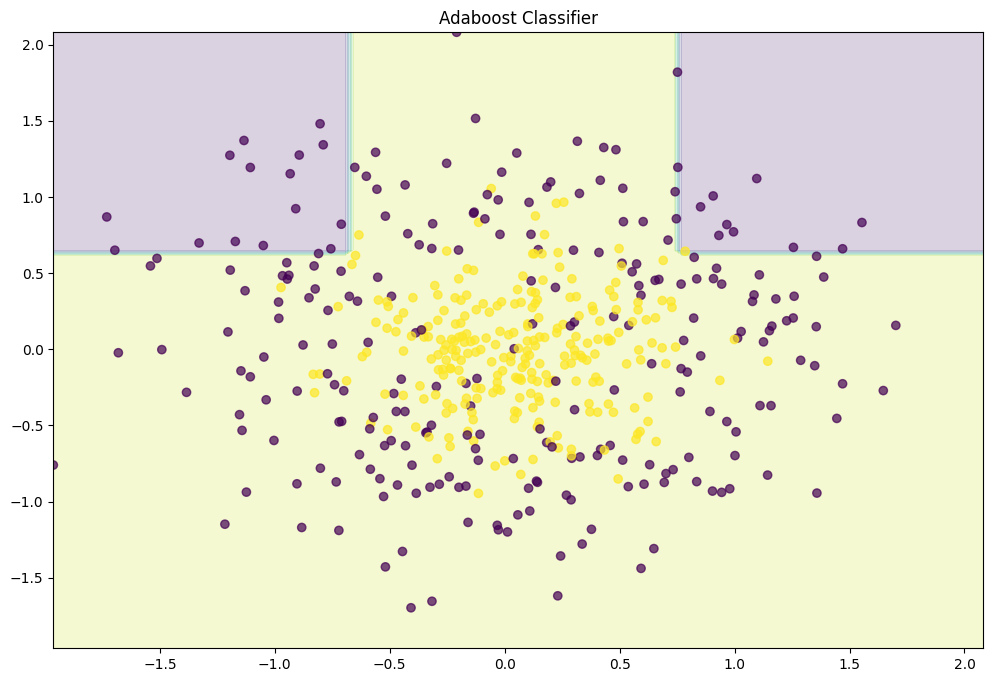

In [101]:
abc = AdaBoostClassifier(n_estimators=3, learning_rate=0.1)
abc.fit(X, y)
ans = abc.predict(X)
print(f"ACCURACY SCORE : {accuracy_score(y, ans)}")

plot_decision_boundary(abc)

ACCURACY SCORE : 0.852


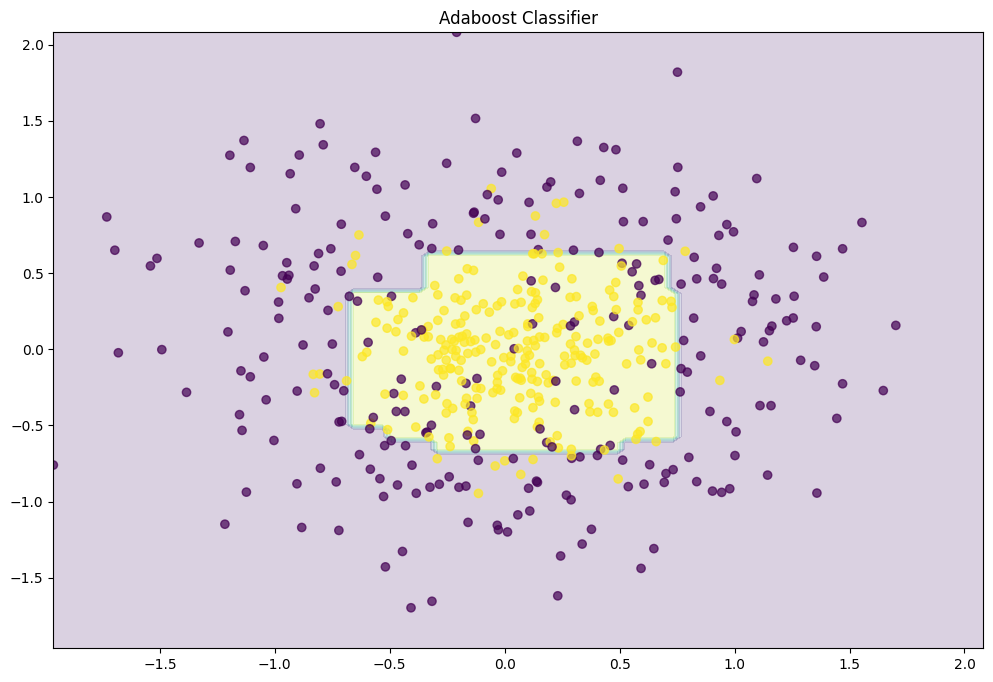

In [102]:
abc = AdaBoostClassifier(n_estimators=1500, learning_rate=0.1)
abc.fit(X, y)
ans = abc.predict(X)
print(f"ACCURACY SCORE : {accuracy_score(y, ans)}")

plot_decision_boundary(abc)

### Using GridSearchCV on AdaBoost

In [103]:
grid = dict()
grid['n_estimators'] = [10, 50, 100, 500]
grid['learning_rate'] = [0.0001, 0.001, 0.01, 0.1, 1.0]
grid['algorithm'] = ['SAMME', 'SAMME.R']


grid_search = GridSearchCV(
    estimator=AdaBoostClassifier(),
    param_grid=grid,
    n_jobs=-1,
    scoring='accuracy'
)

grid_result = grid_search.fit(X, y)
print(f"BEST PARAMETERS : {grid_result.best_params_}")
print()
print(f"BEST SCORE : {grid_result.best_score_}")

BEST PARAMETERS : {'algorithm': 'SAMME', 'learning_rate': 0.1, 'n_estimators': 500}

BEST SCORE : 0.834
